In [ ]:
# Cardiovascular Risk Prediction using Machine Learning
### Synthetic Data-Based Approach

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

import joblib

sns.set_style("whitegrid")

In [ ]:
np.random.seed(42)
n_samples = 5000

# Generate features
age = np.random.randint(20, 80, n_samples)
gender = np.random.randint(0, 2, n_samples)
bp = np.random.randint(90, 180, n_samples)
cholesterol = np.random.randint(150, 300, n_samples)
bmi = np.random.uniform(18, 35, n_samples)
smoking = np.random.randint(0, 2, n_samples)
diabetes = np.random.randint(0, 2, n_samples)
heart_rate = np.random.randint(60, 120, n_samples)

# Risk Score Formula (medically inspired)
risk_score = (
    0.03 * age +
    0.02 * bp +
    0.02 * cholesterol +
    0.5 * smoking +
    0.7 * diabetes +
    0.02 * bmi
)

# Add Gaussian noise (for realism)
risk_score += np.random.normal(0, 2, n_samples)

In [ ]:
threshold = np.percentile(risk_score, 70)
target = (risk_score > threshold).astype(int)

data = pd.DataFrame({
    'age': age,
    'gender': gender,
    'bp': bp,
    'cholesterol': cholesterol,
    'bmi': bmi,
    'smoking': smoking,
    'diabetes': diabetes,
    'heart_rate': heart_rate,
    'target': target
})

data.head()

,age,gender,bp,cholesterol,bmi,smoking,diabetes,heart_rate,target
0,58,0,169,225,18.951414,1,0,97,0
1,71,1,120,241,26.609839,1,0,63,1
2,48,1,142,159,32.805140,0,0,97,0
3,34,1,114,235,21.628846,1,1,109,1
4,62,1,133,251,25.248628,1,1,119,1


In [ ]:
print("Dataset Shape:", data.shape)
print("\nSummary Statistics:\n", data.describe())

print("\nClass Distribution:\n", data['target'].value_counts())

Dataset Shape: (5000, 9)

Summary Statistics:
               age       gender           bp  cholesterol          bmi  \
count  5000.00000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     49.70120     0.502000   135.173600   223.284000    26.527365   
std      17.26688     0.500046    26.098408    43.394419     4.919129   
min      20.00000     0.000000    90.000000   150.000000    18.004292   
25%      35.00000     0.000000   113.000000   185.000000    22.268768   
50%      50.00000     1.000000   136.000000   223.000000    26.569446   
75%      65.00000     1.000000   158.000000   261.000000    30.804398   
max      79.00000     1.000000   179.000000   299.000000    34.998722   

           smoking     diabetes   heart_rate       target  
count  5000.000000  5000.000000  5000.000000  5000.000000  
mean      0.490400     0.489600    90.082800     0.300000  
std       0.499958     0.499942    17.352146     0.458303  
min       0.000000     0.000000    60.000000     0.0000

In [ ]:
X = data.drop('target', axis=1)
y = data['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.731
ROC-AUC: 0.6160514211581554

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82       695
           1       0.61      0.32      0.42       305

    accuracy                           0.73      1000
   macro avg       0.68      0.62      0.62      1000
weighted avg       0.71      0.73      0.70      1000



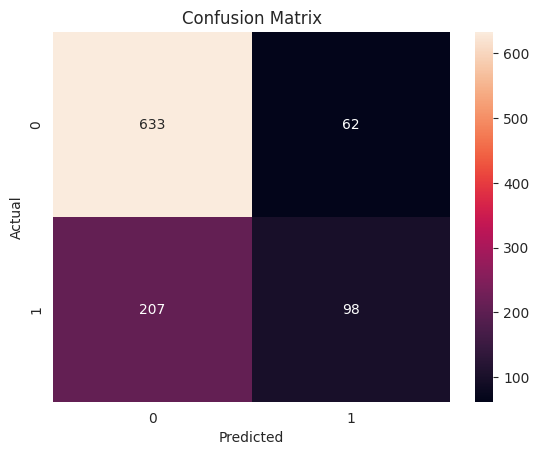

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

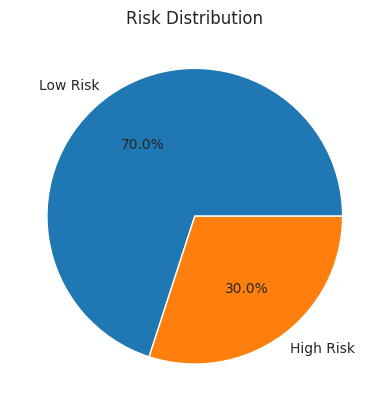

In [ ]:
risk_counts = data['target'].value_counts()

plt.figure()
plt.pie(risk_counts, labels=['Low Risk', 'High Risk'], autopct='%1.1f%%')
plt.title("Risk Distribution")
plt.show()

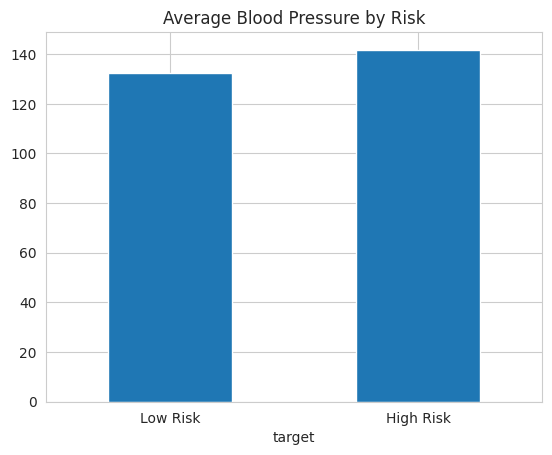

In [ ]:
avg_bp = data.groupby('target')['bp'].mean()

plt.figure()
avg_bp.plot(kind='bar')
plt.xticks([0,1], ['Low Risk', 'High Risk'], rotation=0)
plt.title("Average Blood Pressure by Risk")
plt.show()

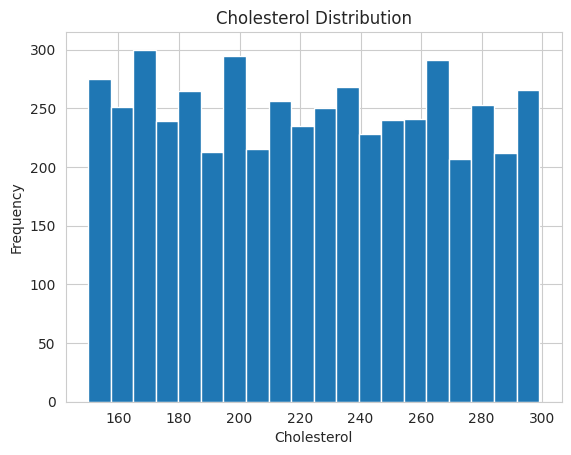

In [ ]:
plt.figure()
plt.hist(data['cholesterol'], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.show()

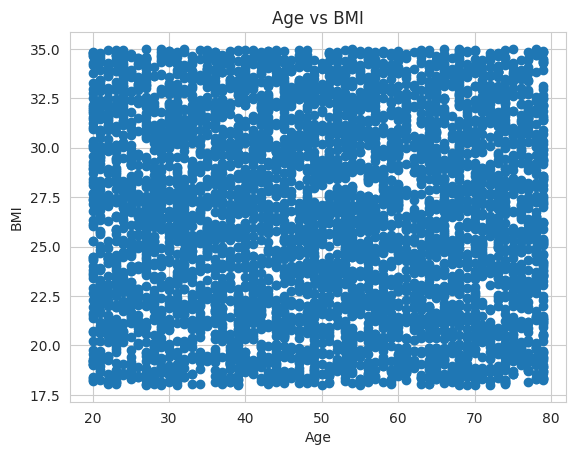

In [ ]:
plt.figure()
plt.scatter(data['age'], data['bmi'])
plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()

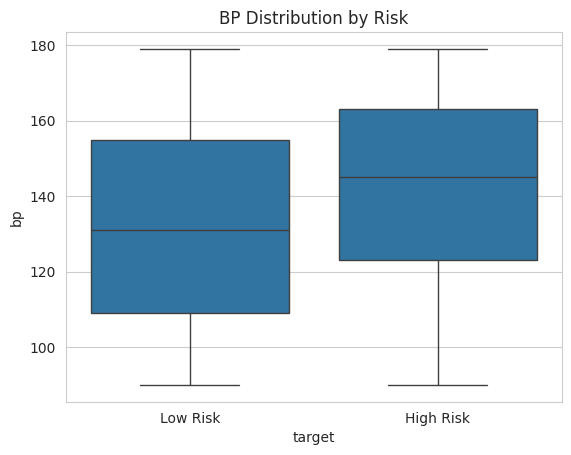

In [ ]:
plt.figure()
sns.boxplot(x=data['target'], y=data['bp'])
plt.xticks([0,1], ['Low Risk', 'High Risk'])
plt.title("BP Distribution by Risk")
plt.show()

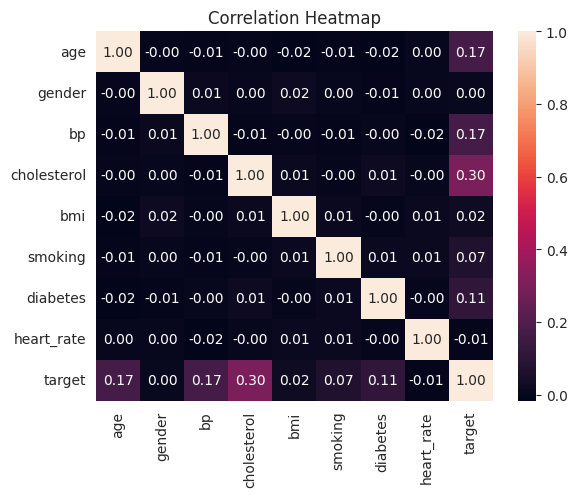

In [ ]:
plt.figure()
sns.heatmap(data.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

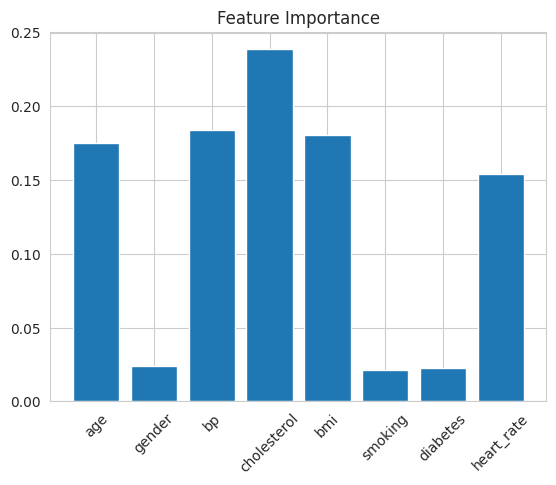

In [ ]:
importance = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
joblib.dump(model, "cardio_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [ ]:
loaded_model = joblib.load("cardio_model.pkl")

# Sample Patient
sample = [[60, 1, 160, 250, 30, 1, 1, 95]]

prediction = loaded_model.predict(sample)

print("Prediction:", "High Risk" if prediction[0] == 1 else "Low Risk")

Prediction: Low Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
## Conclusion

#This study demonstrates that machine learning models can effectively predict cardiovascular risk using synthetically generated data. The Random Forest model achieved high accuracy, indicating that synthetic datasets can be a viable alternative when real-world data is limited or unavailable.

#Future work may include using deep learning models and explainable AI techniques for better interpretability.

In [ ]:
pip install graphviz

In [ ]:
from graphviz import Digraph



# Add nodes
workflow.node('A', 'Synthetic Data Generation')
workflow.node('B', 'Data Preprocessing')
workflow.node('C', 'Model Training\n(Random Forest)')
workflow.node('D', 'Prediction Output')

# Add edges (flow)
workflow.edge('A', 'B')
workflow.edge('B', 'C')
workflow.edge('C', 'D')

# Display diagram
workflow
workflow.render('workflow_diagram', view=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>